In [1]:
import os

# ── CONFIRM this path using Notebook 1 Cell 1 output ──────────
DATASET_PATH = "/kaggle/input/datasets/dgvdeelaka/sinhala-letters-dataset/sinhala_dataset"


MODEL_SAVE_PATH  = "/kaggle/working/models/sinhala_cnn.h5"
LABELMAP_PATH    = "/kaggle/working/models/label_map.json"
LOG_PATH         = "/kaggle/working/training_log.csv"

IMAGE_SIZE  = (64, 64)
BATCH_SIZE  = 32
EPOCHS      = 60

os.makedirs("/kaggle/working/models", exist_ok=True)

print("Configuration set")
print(f"   Dataset path  : {DATASET_PATH}")
print(f"   Model save to : {MODEL_SAVE_PATH}")
print(f"   Image size    : {IMAGE_SIZE}")
print(f"   Batch size    : {BATCH_SIZE}")
print(f"   Max epochs    : {EPOCHS}")

Configuration set
   Dataset path  : /kaggle/input/datasets/dgvdeelaka/sinhala-letters-dataset/sinhala_dataset
   Model save to : /kaggle/working/models/sinhala_cnn.h5
   Image size    : (64, 64)
   Batch size    : 32
   Max epochs    : 60


In [2]:
import os, json, numpy as np, cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

print(f" TensorFlow : {tf.__version__}")
print(f"   GPU active : {len(tf.config.list_physical_devices('GPU')) > 0}")

# Speed up training on GPU
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print(" Mixed precision ON  →  faster GPU training")

2026-03-27 14:32:54.662037: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774621974.869604      25 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774621974.924456      25 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774621975.416948      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774621975.416997      25 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774621975.417000      25 computation_placer.cc:177] computation placer alr

 TensorFlow : 2.19.0
   GPU active : True
 Mixed precision ON  →  faster GPU training


In [3]:
class_folders = sorted(os.listdir(DATASET_PATH))
NUM_CLASSES   = len(class_folders)
letter_to_idx = {letter: idx for idx, letter in enumerate(class_folders)}
label_map     = {str(idx): letter for idx, letter in enumerate(class_folders)}

# Save label_map.json
with open(LABELMAP_PATH, "w", encoding="utf-8") as f:
    json.dump(label_map, f, ensure_ascii=False, indent=2)

print(f" Classes found       : {NUM_CLASSES}")
print(f"   label_map.json saved ")
print(f"\n   First 8 class mappings:")
for k, v in list(label_map.items())[:8]:
    print(f"   [{k}]  →  '{v}'")

 Classes found       : 454
   label_map.json saved 

   First 8 class mappings:
   [0]  →  '187'
   [1]  →  '393'
   [2]  →  '394'
   [3]  →  '400'
   [4]  →  '406'
   [5]  →  '409'
   [6]  →  '414'
   [7]  →  '415'


In [4]:
X        = []
y        = []
skipped  = 0
loaded   = 0

print(" Loading images — please wait...")
print("─" * 50)

for letter, idx in letter_to_idx.items():
    folder = os.path.join(DATASET_PATH, letter)

    for fname in os.listdir(folder):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            continue

        fpath = os.path.join(folder, fname)
        try:
            img = cv2.imread(fpath, cv2.IMREAD_GRAYSCALE)

            if img is None:
                skipped += 1
                continue

            # Resize to standard size
            img = cv2.resize(img, IMAGE_SIZE)

            # Invert: make letter WHITE on BLACK background
            # (CNN learns better this way)
            img = cv2.bitwise_not(img)

            X.append(img)
            y.append(idx)
            loaded += 1

            # Print progress every 500 images
            if loaded % 500 == 0:
                print(f"   Loaded {loaded:,} images so far...")

        except Exception as e:
            skipped += 1

# Convert lists to numpy arrays
X = np.array(X, dtype='float32') / 255.0       # normalize to [0.0 – 1.0]
X = X.reshape(-1, IMAGE_SIZE[0], IMAGE_SIZE[1], 1)  # add channel dimension
y = np.array(y, dtype='int32')

print(f"\n Loading complete!")
print(f"   X shape    : {X.shape}  ← (images, height, width, channels)")
print(f"   y shape    : {y.shape}")
print(f"   Loaded     : {loaded:,} images")
print(f"   Skipped    : {skipped} corrupted/unreadable files")
print(f"   Memory use : {X.nbytes / 1024**2:.1f} MB")

 Loading images — please wait...
──────────────────────────────────────────────────
   Loaded 500 images so far...
   Loaded 1,000 images so far...
   Loaded 1,500 images so far...
   Loaded 2,000 images so far...
   Loaded 2,500 images so far...
   Loaded 3,000 images so far...
   Loaded 3,500 images so far...
   Loaded 4,000 images so far...
   Loaded 4,500 images so far...
   Loaded 5,000 images so far...
   Loaded 5,500 images so far...
   Loaded 6,000 images so far...
   Loaded 6,500 images so far...
   Loaded 7,000 images so far...
   Loaded 7,500 images so far...
   Loaded 8,000 images so far...
   Loaded 8,500 images so far...
   Loaded 9,000 images so far...
   Loaded 9,500 images so far...
   Loaded 10,000 images so far...
   Loaded 10,500 images so far...
   Loaded 11,000 images so far...
   Loaded 11,500 images so far...
   Loaded 12,000 images so far...
   Loaded 12,500 images so far...
   Loaded 13,000 images so far...
   Loaded 13,500 images so far...
   Loaded 14,000 im

In [5]:
# One-hot encode: integer → array  e.g. 3 → [0,0,0,1,0,...]
y_encoded = to_categorical(y, num_classes=NUM_CLASSES)

# ── Split 1: 85% trainval, 15% test ───────────────────────────
X_tv, X_test, y_tv, y_test = train_test_split(
    X, y_encoded,
    test_size=0.15,
    stratify=y,           # keeps class balance equal in each split
    random_state=42
)

# ── Split 2: 85% train, 15% val (from trainval portion) ───────
y_tv_int = np.argmax(y_tv, axis=1)   # need int for stratify
X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv,
    test_size=0.15,
    stratify=y_tv_int,
    random_state=42
)

print(" Data split complete!")
print(f"   Training   : {len(X_train):,} images  ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validation : {len(X_val):,}  images  ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test       : {len(X_test):,}  images  ({len(X_test)/len(X)*100:.1f}%)")
print(f"   ─────────────────────────────────")
print(f"   Total      : {len(X):,} images")

 Data split complete!
   Training   : 62,958 images  (72.2%)
   Validation : 11,111  images  (12.8%)
   Test       : 13,072  images  (15.0%)
   ─────────────────────────────────
   Total      : 87,141 images


 Augmentation configured
   Steps per epoch : 1967


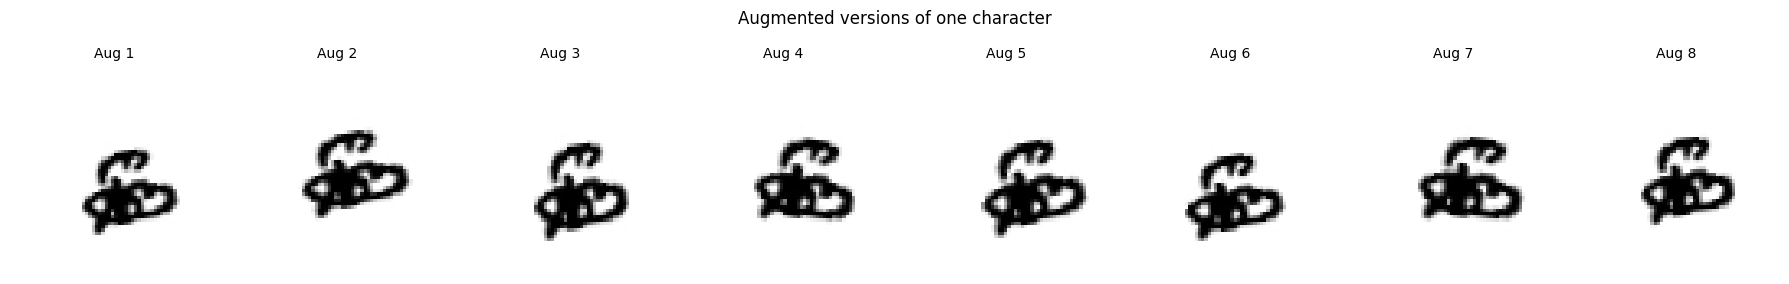

In [6]:
# Augmentation = create slightly modified versions of training images
# This teaches the model to handle different:
#   - writing angles (rotation)
#   - writing positions (shift)
#   - writing sizes (zoom)
#   - pen pressure variations (shear)

train_aug = ImageDataGenerator(
    rotation_range=12,       # rotate up to ±12°
    width_shift_range=0.10,  # shift left/right up to 10%
    height_shift_range=0.10, # shift up/down up to 10%
    zoom_range=0.12,         # zoom in/out up to 12%
    shear_range=0.10,        # shear up to 10%
    fill_mode='nearest'      # fill gaps with nearest pixel value
)

train_gen = train_aug.flow(X_train, y_train, batch_size=BATCH_SIZE)

print(" Augmentation configured")
print(f"   Steps per epoch : {len(X_train) // BATCH_SIZE}")

# Show 8 augmented versions of one character
sample = X_train[0:1]
fig, axes = plt.subplots(1, 8, figsize=(18, 3))
count = 0
for batch_X, _ in train_aug.flow(sample, np.zeros((1,1)), batch_size=1):
    axes[count].imshow(batch_X[0, :, :, 0], cmap='gray')
    axes[count].set_title(f"Aug {count+1}", fontsize=10)
    axes[count].axis('off')
    count += 1
    if count >= 8:
        break
plt.suptitle("Augmented versions of one character", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
#build CNN model

def build_sinhala_cnn(input_shape, num_classes):
    inp = layers.Input(shape=input_shape, name="input")

    # ── Block 1: detect basic strokes ──────────────────────────
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 2: detect character parts ────────────────────────
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    # ── Block 3: detect full character shapes ───────────────────
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.30)(x)

    # ── Block 4: detect complex features ───────────────────────
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(256, 3, padding='same', activation='relu')(x)
    x = layers.GlobalAveragePooling2D()(x)  # reduces overfitting

    # ── Classifier head ─────────────────────────────────────────
    x = layers.Dense(512, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.50)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.30)(x)

    # ── Output layer ─────────────────────────────────────────────
    # dtype=float32 required when mixed_precision is enabled
    out = layers.Dense(num_classes, activation='softmax',
                       dtype='float32', name="output")(x)

    return models.Model(inp, out, name="SinhalaOCR_CNN")


model = build_sinhala_cnn(
    input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 1),
    num_classes=NUM_CLASSES
)

model.summary()
print(f"\n Total parameters : {model.count_params():,}")

I0000 00:00:1774622371.960217      25 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "SinhalaOCR_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 64, 64, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 1,555,238 (5.93 MB)

 Trainable params: 1,553,254 (5.93 MB)

 Non-trainable params: 1,984 (7.75 KB)


 Total parameters : 1,555,238


In [8]:
#compile model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
print(" Model compiled")
print("   Optimizer     : Adam  (lr=0.001)")
print("   Loss function : categorical_crossentropy")
print("   Metric        : accuracy")

 Model compiled
   Optimizer     : Adam  (lr=0.001)
   Loss function : categorical_crossentropy
   Metric        : accuracy


In [9]:
cb_list = [

    # Save the model every time validation accuracy improves
    callbacks.ModelCheckpoint(
        filepath=MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,       # only overwrite if better
        save_weights_only=False,   # save full model not just weights
        mode='max',
        verbose=1
    ),

    # Stop training early if no improvement for 12 epochs
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=12,
        restore_best_weights=True, # revert to best epoch weights
        verbose=1
    ),

    # Halve learning rate if val_loss stops improving for 5 epochs
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    ),

    # Write every epoch result to CSV
    callbacks.CSVLogger(LOG_PATH)
]

print(" Callbacks ready:")
print("   ✔ ModelCheckpoint  — saves best model automatically")
print("   ✔ EarlyStopping    — stops if stuck for 12 epochs")
print("   ✔ ReduceLROnPlateau — halves LR when stuck for 5 epochs")
print("   ✔ CSVLogger        — saves full training log to CSV")

 Callbacks ready:
   ✔ ModelCheckpoint  — saves best model automatically
   ✔ EarlyStopping    — stops if stuck for 12 epochs
   ✔ ReduceLROnPlateau — halves LR when stuck for 5 epochs
   ✔ CSVLogger        — saves full training log to CSV


In [10]:
print(" Training started!")
print(f"   Classes   : {NUM_CLASSES}")
print(f"   Train set : {len(X_train):,} images")
print(f"   Val set   : {len(X_val):,} images")
print(f"   Max epochs: {EPOCHS}")
print("─" * 50)

history = model.fit(
    train_gen,
    epochs=EPOCHS,
    steps_per_epoch=len(X_train) // BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=cb_list,
    verbose=1
)

best_acc = max(history.history['val_accuracy'])
print(f"\n{'─'*50}")
print(f" Training complete!")
print(f"   Best validation accuracy : {best_acc*100:.2f}%")
print(f"   Epochs run               : {len(history.history['accuracy'])}")
print(f"   Model saved to           : {MODEL_SAVE_PATH}")

 Training started!
   Classes   : 454
   Train set : 62,958 images
   Val set   : 11,111 images
   Max epochs: 60
──────────────────────────────────────────────────
Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1774622378.541666      68 service.cc:152] XLA service 0x7e3054002de0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774622378.541711      68 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1774622379.679439      68 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1774622404.280989      68 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1966/1967 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.0101 - loss: 5.8893
Epoch 1: val_accuracy improved from -inf to 0.08568, saving model to /kaggle/working/models/sinhala_cnn.h5


1967/1967 ━━━━━━━━━━━━━━━━━━━━ 98s 34ms/step - accuracy: 0.0102 - loss: 5.8888 - val_accuracy: 0.0857 - val_loss: 4.0173 - learning_rate: 0.0010
Epoch 2/60
   1/1967 ━━━━━━━━━━━━━━━━━━━━ 26s 13ms/step - accuracy: 0.0938 - loss: 4.2560

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

1967/1967 ━━━━━━━━━━━━━━━━━━━━ 2s 790us/step - accuracy: 0.8438 - loss: 0.5308 - val_accuracy: 0.9122 - val_loss: 0.2765 - learning_rate: 2.5000e-04
Epoch 53/60
1966/1967 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8551 - loss: 0.4693
Epoch 53: val_accuracy improved from 0.91216 to 0.91423, saving model to /kaggle/working/models/sinhala_cnn.h5


1967/1967 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8551 - loss: 0.4693 - val_accuracy: 0.9142 - val_loss: 0.2715 - learning_rate: 2.5000e-04
Epoch 54/60
   1/1967 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8750 - loss: 0.4645
Epoch 54: val_accuracy did not improve from 0.91423
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 1s 719us/step - accuracy: 0.8750 - loss: 0.4645 - val_accuracy: 0.9141 - val_loss: 0.2714 - learning_rate: 2.5000e-04
Epoch 55/60
1965/1967 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8490 - loss: 0.4789
Epoch 55: val_accuracy improved from 0.91423 to 0.91603, saving model to /kaggle/working/models/sinhala_cnn.h5


1967/1967 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8490 - loss: 0.4789 - val_accuracy: 0.9160 - val_loss: 0.2671 - learning_rate: 2.5000e-04
Epoch 56/60
   1/1967 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9062 - loss: 0.2408
Epoch 56: val_accuracy improved from 0.91603 to 0.91612, saving model to /kaggle/working/models/sinhala_cnn.h5


1967/1967 ━━━━━━━━━━━━━━━━━━━━ 2s 783us/step - accuracy: 0.9062 - loss: 0.2408 - val_accuracy: 0.9161 - val_loss: 0.2691 - learning_rate: 2.5000e-04
Epoch 57/60
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8531 - loss: 0.4639
Epoch 57: val_accuracy did not improve from 0.91612
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8531 - loss: 0.4639 - val_accuracy: 0.9159 - val_loss: 0.2646 - learning_rate: 2.5000e-04
Epoch 58/60
   1/1967 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.9375 - loss: 0.3791
Epoch 58: val_accuracy did not improve from 0.91612
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 1s 744us/step - accuracy: 0.9375 - loss: 0.3791 - val_accuracy: 0.9158 - val_loss: 0.2644 - learning_rate: 2.5000e-04
Epoch 59/60
1966/1967 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8557 - loss: 0.4619
Epoch 59: val_accuracy improved from 0.91612 to 0.91765, saving model to /kaggle/working/models/sinhala_cnn.h5


1967/1967 ━━━━━━━━━━━━━━━━━━━━ 37s 19ms/step - accuracy: 0.8557 - loss: 0.4619 - val_accuracy: 0.9176 - val_loss: 0.2604 - learning_rate: 2.5000e-04
Epoch 60/60
   1/1967 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8750 - loss: 0.4451
Epoch 60: val_accuracy did not improve from 0.91765
1967/1967 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.8750 - loss: 0.4451 - val_accuracy: 0.9176 - val_loss: 0.2607 - learning_rate: 2.5000e-04
Restoring model weights from the end of the best epoch: 59.

──────────────────────────────────────────────────
 Training complete!
   Best validation accuracy : 91.76%
   Epochs run               : 60
   Model saved to           : /kaggle/working/models/sinhala_cnn.h5


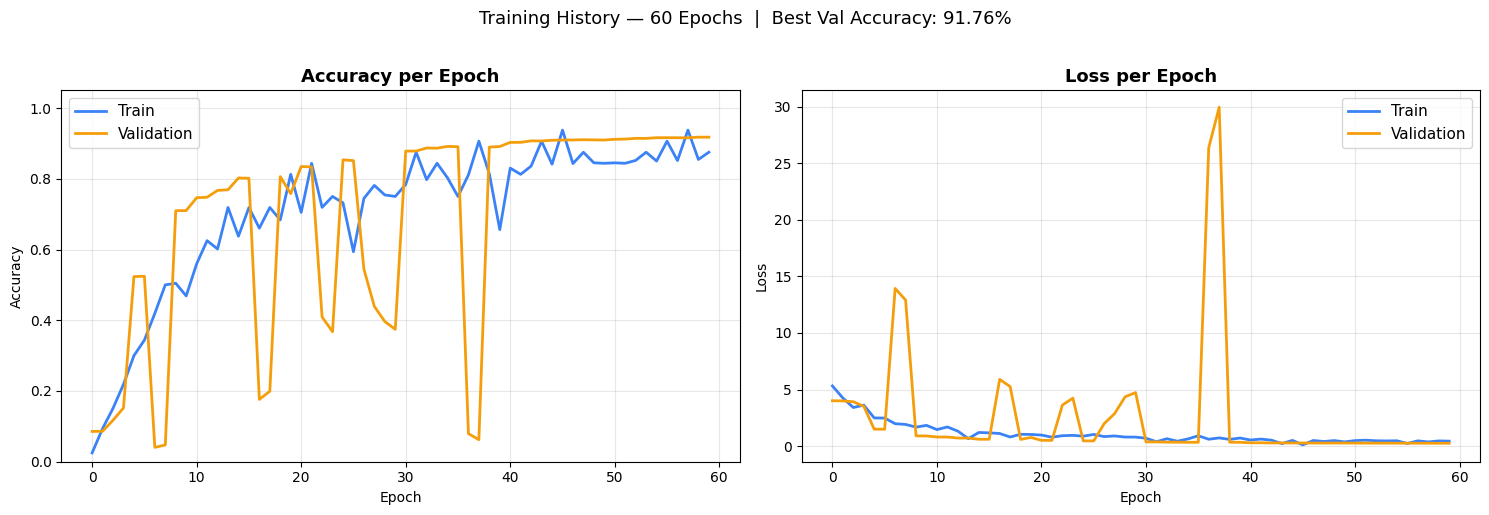

Chart saved → /kaggle/working/training_history.png


In [11]:
epochs_ran = len(history.history['accuracy'])
best_acc   = max(history.history['val_accuracy'])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy
a1.plot(history.history['accuracy'],     label='Train',
        color='#3b82f6', linewidth=2)
a1.plot(history.history['val_accuracy'], label='Validation',
        color='#f59e0b', linewidth=2)
a1.set_title('Accuracy per Epoch', fontsize=13, fontweight='bold')
a1.set_xlabel('Epoch'); a1.set_ylabel('Accuracy')
a1.legend(fontsize=11); a1.grid(True, alpha=0.3)
a1.set_ylim([0, 1.05])

# Loss
a2.plot(history.history['loss'],     label='Train',
        color='#3b82f6', linewidth=2)
a2.plot(history.history['val_loss'], label='Validation',
        color='#f59e0b', linewidth=2)
a2.set_title('Loss per Epoch', fontsize=13, fontweight='bold')
a2.set_xlabel('Epoch'); a2.set_ylabel('Loss')
a2.legend(fontsize=11); a2.grid(True, alpha=0.3)

plt.suptitle(
    f"Training History — {epochs_ran} Epochs  |  "
    f"Best Val Accuracy: {best_acc*100:.2f}%",
    fontsize=13, y=1.02
)
plt.tight_layout()
plt.savefig("/kaggle/working/training_history.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("Chart saved → /kaggle/working/training_history.png")

In [12]:
from sklearn.metrics import classification_report
from tensorflow.keras.models import load_model

# Load the best saved model
best_model = load_model(MODEL_SAVE_PATH)

# Overall accuracy
test_loss, test_acc = best_model.evaluate(X_test, y_test, verbose=0)
print(f"{'─'*50}")
print(f" FINAL TEST RESULTS")
print(f"{'─'*50}")
print(f"   Test Accuracy : {test_acc*100:.2f}%")
print(f"   Test Loss     : {test_loss:.4f}")
print(f"{'─'*50}")

# Per-class breakdown
y_pred       = best_model.predict(X_test, verbose=0)
y_pred_class = np.argmax(y_pred, axis=1)
y_true_class = np.argmax(y_test, axis=1)
target_names = [label_map[str(i)] for i in range(NUM_CLASSES)]

print("\n Per-class Report (precision / recall / f1):")
print(classification_report(
    y_true_class, y_pred_class,
    target_names=target_names
))

──────────────────────────────────────────────────
 FINAL TEST RESULTS
──────────────────────────────────────────────────
   Test Accuracy : 92.07%
   Test Loss     : 0.2530
──────────────────────────────────────────────────

 Per-class Report (precision / recall / f1):
                   precision    recall  f1-score   support

              187       1.00      1.00      1.00        23
              393       1.00      0.89      0.94        28
              394       0.96      0.86      0.91        29
              400       0.92      0.76      0.83        29
              406       0.93      0.86      0.89        29
              409       0.94      1.00      0.97        29
              414       0.90      0.97      0.93        29
              415       0.80      0.97      0.88        29
              416       0.96      0.93      0.95        29
              417       0.88      0.97      0.92        29
              418       0.93      0.96      0.95        28
              419   

In [13]:
print(" All output files in /kaggle/working/")
print("─" * 55)

for root, dirs, files in os.walk("/kaggle/working"):
    for fname in files:
        fpath    = os.path.join(root, fname)
        size_kb  = os.path.getsize(fpath) / 1024
        rel_path = fpath.replace('/kaggle/working/', '')
        unit     = "KB"
        size     = size_kb
        if size_kb > 1024:
            size = size_kb / 1024
            unit = "MB"
        print(f"  {rel_path:<40} {size:.1f} {unit}")

print(f"\n Must-download files:")
print(f"   1.  models/sinhala_cnn.h5     ← trained AI model")
print(f"   2.  models/label_map.json     ← letter index map")

 All output files in /kaggle/working/
───────────────────────────────────────────────────────
  training_log.csv                         5.7 KB
  __notebook__.ipynb                       8.8 MB
  training_history.png                     114.4 KB
  models/label_map.json                    8.8 KB
  models/sinhala_cnn.h5                    17.9 MB

 Must-download files:
   1.  models/sinhala_cnn.h5     ← trained AI model
   2.  models/label_map.json     ← letter index map
